
#  Fitnessdaten Visualisieren 


**Was wird gemacht?**
- Laden & Bereinigen deiner Daten
- Abgeleitete Metriken (Pace, Geschwindigkeit, Wochensummen)
- **Zeitreihen** (Distanz, Pace, HF), **Korrelationen**, **Scatter**



In [1]:
import os
from pathlib import Path
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib Grundeinstellungen (keine Styles/Farben festgelegt)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

# Ordner für Ausgaben
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print('Output-Verzeichnis:', OUTPUT_DIR.resolve())


Output-Verzeichnis: /Users/thuvarakayograjah/Documents/FHGR 5.Semester/Data Science/outputs


In [8]:

# --Datei & Spaltenzuordnung --
DATA_PATH = 'runs_formatted_date.csv'  

# Mappiung
COLUMN_MAP = {
    'date': 'date',
    'distance_km': 'distance_km',
    # mindestens eine der folgenden drei Dauerquellen ausfüllen:
    'duration_min': 'duration_min',     # z. B. 42.5
    'duration_sec': None,               # z. B. 2550
    'duration_hms': None,               # z. B. '00:42:30'
    # optionale Spalten:
    'avg_hr': 'avg_hr',
    'calories': 'calories',
    'elevation_gain_m': 'elevation_gain_m',
    'cadence_spm': 'cadence_spm',
}

DURATION_SOURCE = 'min'  

assert Path(DATA_PATH).exists(), f'Datei nicht gefunden: {DATA_PATH}'
print('Datei gefunden:', DATA_PATH)


Datei gefunden: runs_formatted_date.csv



## 2) Daten laden


In [20]:

# -- Laden der Daten --
if DATA_PATH.lower().endswith('.csv'):
    df_raw = pd.read_csv(DATA_PATH, skiprows=3)
elif DATA_PATH.lower().endswith('.xlsx'):
    df_raw = pd.read_excel(DATA_PATH, skiprows=3)
else:
    raise ValueError('Unterstützt werden nur .csv oder .xlsx')

print(df_raw.shape)
print(df_raw.columns)
df_raw.head()




(162, 100)
Index(['Activity ID', 'Activity Date', 'Formatted Date', 'Activity Name',
       'Activity Type', 'Activity Description', 'Elapsed Time', 'Distance',
       'Max Heart Rate', 'Relative Effort', 'Commute', 'Activity Private Note',
       'Activity Gear', 'Filename', 'Athlete Weight', 'Bike Weight',
       'Elapsed Time.1', 'Moving Time', 'Distance.1', 'Max Speed',
       'Average Speed', 'Elevation Gain', 'Elevation Loss', 'Elevation Low',
       'Elevation High', 'Max Grade', 'Average Grade',
       'Average Positive Grade', 'Average Negative Grade', 'Max Cadence',
       'Average Cadence', 'Max Heart Rate.1', 'Average Heart Rate',
       'Max Watts', 'Average Watts', 'Calories', 'Max Temperature',
       'Average Temperature', 'Relative Effort.1', 'Total Work',
       'Number of Runs', 'Uphill Time', 'Downhill Time', 'Other Time',
       'Perceived Exertion', 'Type', 'Start Time', 'Weighted Average Power',
       'Power Count', 'Prefer Perceived Exertion', 'Perceived Relati

,Activity ID,Activity Date,Formatted Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,...,Intensity,Average Grade Adjusted Pace,Timer Time,Total Cycles,Recovery,With Pet,Competition,Long Run,For a Cause,Media
0,8486924267,"Feb 1, 2023, 10:59:24 AM",01/02/2023 10:59,Lunch Run,Run,NaN,2648,4.82,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8503132155,"Feb 4, 2023, 12:06:25 PM",04/02/2023 12:06,Afternoon Run,Run,NaN,1919,4.33,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8519630952,"Feb 7, 2023, 10:08:51 AM",07/02/2023 10:08,Lunch Run,Run,NaN,2152,4.68,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8530911707,"Feb 9, 2023, 9:35:03 AM",09/02/2023 09:35,Morning Run,Run,NaN,1914,4.48,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8536230406,"Feb 10, 2023, 9:28:03 AM",10/02/2023 09:28,Morning Run,Run,NaN,2055,3.61,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Liste der Spalten, die du behalten willst
keep = [
    "Formatted Date",
    "Activity Date",
    "Distance",
    "Elapsed Time",
    "Average Speed",
    "Calories",
    "Average Heart Rate"
]

# Nur diese Spalten behalten
df = df_raw[keep]

# Prüfen
df.head()


,Formatted Date,Activity Date,Distance,Elapsed Time,Average Speed,Calories,Average Heart Rate
0,01/02/2023 10:59,"Feb 1, 2023, 10:59:24 AM",4.82,2648,2.074,NaN,NaN
1,04/02/2023 12:06,"Feb 4, 2023, 12:06:25 PM",4.33,1919,2.275,NaN,NaN
2,07/02/2023 10:08,"Feb 7, 2023, 10:08:51 AM",4.68,2152,2.294,NaN,NaN
3,09/02/2023 09:35,"Feb 9, 2023, 9:35:03 AM",4.48,1914,2.347,NaN,NaN
4,10/02/2023 09:28,"Feb 10, 2023, 9:28:03 AM",3.61,2055,1.918,NaN,NaN


## 3.) Datenbereinigung und Auffüllen fehlender Werte & Feature Engineering


- fehlende Werte ersetzen
- Datumsformat parsen
- Dauer in **Minuten** vereinheitlichen
- Pace (min/km) & Geschwindigkeit (km/h) berechnen


In [24]:
# Durchschnitt pro Distanzklasse (
df["Distance_rounded"] = df["Distance"].round(0)

# Kalorien nach Distanzmittelwert ersetzen
df["Calories"] = df.groupby("Distance_rounded")["Calories"].transform(
    lambda x: x.fillna(x.mean())
)

# Herzfrequenz ähnlich nach Distanz auffüllen
df["Average Heart Rate"] = df.groupby("Distance_rounded")["Average Heart Rate"].transform(
    lambda x: x.fillna(x.mean())
)

df.head(10)

/var/folders/qr/hqmhm6pn7s73hmvnyjxsq9hr0000gn/T/ipykernel_9320/208434672.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Distance_rounded"] = df["Distance"].round(0)
/var/folders/qr/hqmhm6pn7s73hmvnyjxsq9hr0000gn/T/ipykernel_9320/208434672.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Calories"] = df.groupby("Distance_rounded")["Calories"].transform(
/var/folders/qr/hqmhm6pn7s73hmvnyjxsq9hr0000gn/T/ipykernel_9320/208434672.py:10: SettingWithCopyWarning: 
A value is trying to be set on a c

,Formatted Date,Activity Date,Distance,Elapsed Time,Average Speed,Calories,Average Heart Rate,Distance_rounded
0,01/02/2023 10:59,"Feb 1, 2023, 10:59:24 AM",4.82,2648,2.074,381.000000,146.333333,5.0
1,04/02/2023 12:06,"Feb 4, 2023, 12:06:25 PM",4.33,1919,2.275,299.611111,144.944444,4.0
2,07/02/2023 10:08,"Feb 7, 2023, 10:08:51 AM",4.68,2152,2.294,381.000000,146.333333,5.0
3,09/02/2023 09:35,"Feb 9, 2023, 9:35:03 AM",4.48,1914,2.347,299.611111,144.944444,4.0
4,10/02/2023 09:28,"Feb 10, 2023, 9:28:03 AM",3.61,2055,1.918,299.611111,144.944444,4.0
5,13/02/2023 07:55,"Feb 13, 2023, 7:55:16 AM",3.47,1715,2.209,227.750000,140.750000,3.0
6,20/02/2023 07:02,"Feb 20, 2023, 7:02:22 AM",2.67,1162,2.357,227.750000,140.750000,3.0
7,25/02/2023 09:41,"Feb 25, 2023, 9:41:57 AM",3.76,1524,2.492,299.611111,144.944444,4.0
8,28/02/2023 06:57,"Feb 28, 2023, 6:57:33 AM",3.41,1454,2.374,227.750000,140.750000,3.0
9,07/03/2023 06:27,"Mar 7, 2023, 6:27:14 AM",3.34,1489,2.269,227.750000,140.750000,3.0


In [36]:


# --- Spalten richtig zuordnen ---
df = df.copy()
df = df.rename(columns={
    'Formatted Date': 'date',
    'Distance': 'distance_km',
    'Elapsed Time': 'duration_sec',
    'Average Heart Rate': 'avg_hr',
    'Calories': 'calories',
    'Elevation Gain': 'elevation_gain_m'
})

# --- Datum parsen ---
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# --- Dauer in Minuten ---
if 'duration_min' in df.columns:
    df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')
elif 'duration_sec' in df.columns:
    df['duration_min'] = pd.to_numeric(df['duration_sec'], errors='coerce') / 60
elif 'duration_hms' in df.columns:
    def hms_to_min(x):
        try:
            h, m, s = [int(p) for p in str(x).split(':')]
            return h*60 + m + s/60
        except Exception:
            return np.nan
    df['duration_min'] = df['duration_hms'].apply(hms_to_min)

# --- Distanz in km ---
df['distance_km'] = pd.to_numeric(df['distance_km'], errors='coerce')

# Falls Distanz in Metern ist (Strava exportiert manchmal Meter):
if df['distance_km'].median() > 100:  
    df['distance_km'] = df['distance_km'] / 1000

# --- Abgeleitete Kennzahlen ---
df['pace_min_per_km'] = df['duration_min'] / df['distance_km']           # min/km
df['speed_kmh'] = df['distance_km'] / (df['duration_min'] / 60)          # km/h

# --- Zeitmerkmale ---
df['weekday'] = df['date'].dt.day_name()
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['year'] = df['date'].dt.year.astype(int)
df['month'] = df['date'].dt.to_period('M').astype(str)
df['hour'] = df['date'].dt.hour

# --- Optionale numerische Spalten ---
for col in ['avg_hr', 'calories', 'elevation_gain_m']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Ergebnis prüfen ---
print(" Daten bereinigt")
print(f"Zeilen: {len(df)} | Spalten: {list(df.columns)}")
print(f"Datumsbereich: {df['date'].min().date()} → {df['date'].max().date()}")
df.head()


 Daten bereinigt
Zeilen: 64 | Spalten: ['Activity ID', 'Activity Date', 'date', 'Activity Name', 'Activity Type', 'Activity Description', 'duration_sec', 'distance_km', 'Max Heart Rate', 'Relative Effort', 'Commute', 'Activity Private Note', 'Activity Gear', 'Filename', 'Athlete Weight', 'Bike Weight', 'Elapsed Time.1', 'Moving Time', 'Distance.1', 'Max Speed', 'Average Speed', 'elevation_gain_m', 'Elevation Loss', 'Elevation Low', 'Elevation High', 'Max Grade', 'Average Grade', 'Average Positive Grade', 'Average Negative Grade', 'Max Cadence', 'Average Cadence', 'Max Heart Rate.1', 'avg_hr', 'Max Watts', 'Average Watts', 'calories', 'Max Temperature', 'Average Temperature', 'Relative Effort.1', 'Total Work', 'Number of Runs', 'Uphill Time', 'Downhill Time', 'Other Time', 'Perceived Exertion', 'Type', 'Start Time', 'Weighted Average Power', 'Power Count', 'Prefer Perceived Exertion', 'Perceived Relative Effort', 'Commute.1', 'Total Weight Lifted', 'From Upload', 'Grade Adjusted Distanc

,Activity ID,Activity Date,date,Activity Name,Activity Type,Activity Description,duration_sec,distance_km,Max Heart Rate,Relative Effort,...,For a Cause,Media,duration_min,pace_min_per_km,speed_kmh,weekday,week,year,month,hour
0,8486924267,"Feb 1, 2023, 10:59:24 AM",2023-01-02 10:59:00,Lunch Run,Run,NaN,2648,4.82,NaN,NaN,...,NaN,NaN,44.133333,9.156293,6.552870,Monday,1,2023,2023-01,10
1,8503132155,"Feb 4, 2023, 12:06:25 PM",2023-04-02 12:06:00,Afternoon Run,Run,NaN,1919,4.33,NaN,NaN,...,NaN,NaN,31.983333,7.386451,8.122981,Sunday,13,2023,2023-04,12
2,8519630952,"Feb 7, 2023, 10:08:51 AM",2023-07-02 10:08:00,Lunch Run,Run,NaN,2152,4.68,NaN,NaN,...,NaN,NaN,35.866667,7.663818,7.828996,Sunday,26,2023,2023-07,10
3,8530911707,"Feb 9, 2023, 9:35:03 AM",2023-09-02 09:35:00,Morning Run,Run,NaN,1914,4.48,NaN,NaN,...,NaN,NaN,31.900000,7.120536,8.426332,Saturday,35,2023,2023-09,9
4,8536230406,"Feb 10, 2023, 9:28:03 AM",2023-10-02 09:28:00,Morning Run,Run,NaN,2055,3.61,NaN,NaN,...,NaN,NaN,34.250000,9.487535,6.324088,Monday,40,2023,2023-10,9


***PLOTS UND HEATMAP***

**Geschwindigkeit vs. Distanz**

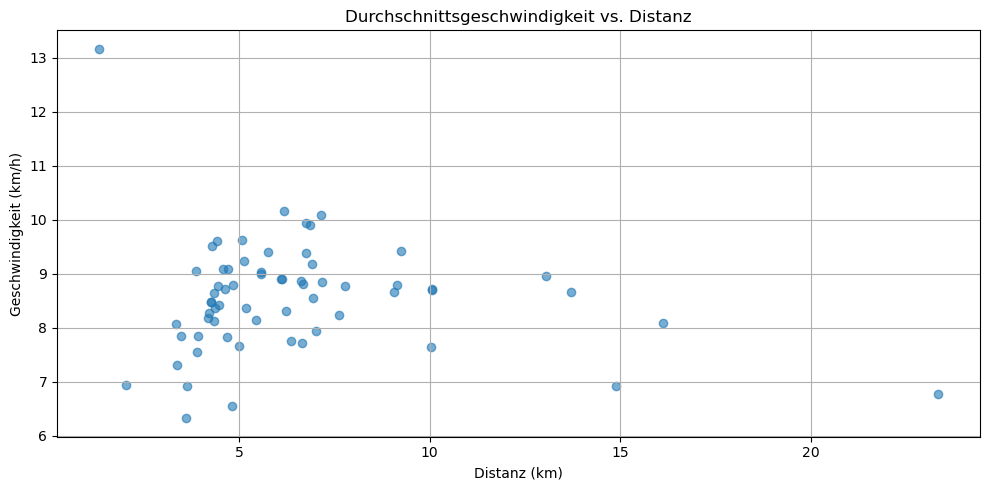

In [32]:
import matplotlib.pyplot as plt
plt.scatter(df["distance_km"], df["speed_kmh"], alpha=0.6)
plt.title("Durchschnittsgeschwindigkeit vs. Distanz")
plt.xlabel("Distanz (km)")
plt.ylabel("Geschwindigkeit (km/h)")
plt.tight_layout()
plt.show()


**Tageszeit & Leistung**

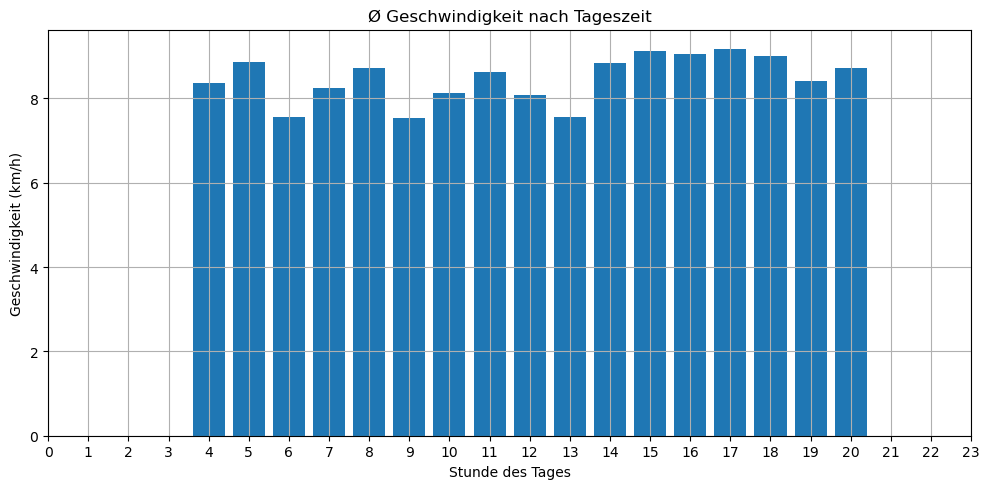

In [33]:
speed_by_hour = df.groupby("hour")["speed_kmh"].mean()

plt.bar(speed_by_hour.index, speed_by_hour.values)
plt.title("Ø Geschwindigkeit nach Tageszeit")
plt.xlabel("Stunde des Tages")
plt.ylabel("Geschwindigkeit (km/h)")
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()


**Energieverbrauch vs. Distanz**

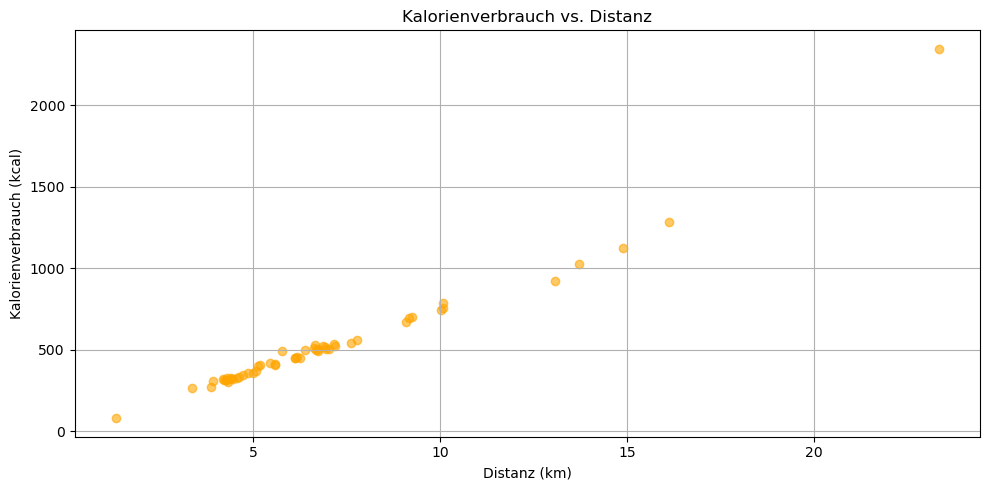

In [34]:
plt.scatter(df["distance_km"], df["calories"], alpha=0.6, color="orange")
plt.title("Kalorienverbrauch vs. Distanz")
plt.xlabel("Distanz (km)")
plt.ylabel("Kalorienverbrauch (kcal)")
plt.tight_layout()
plt.show()


**Heatmap aller Korrelationen**

In [41]:
! pip install seaborn
import seaborn as sns

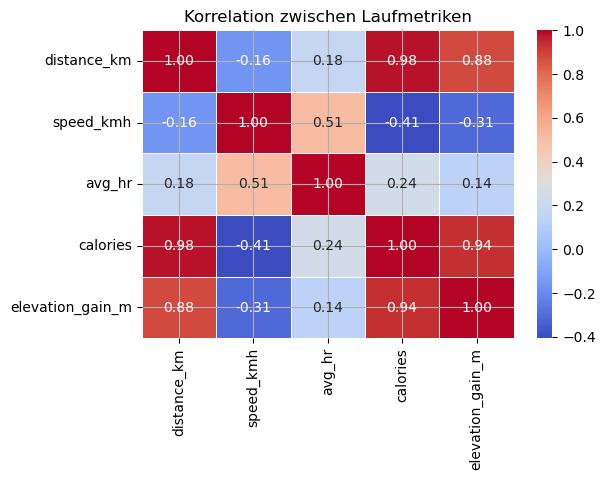

In [42]:
plt.figure(figsize=(6,4))
corr = df[["distance_km", "speed_kmh", "avg_hr", "calories", "elevation_gain_m"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korrelation zwischen Laufmetriken")
plt.show()


**Streuung und Ausreisser erkennen**

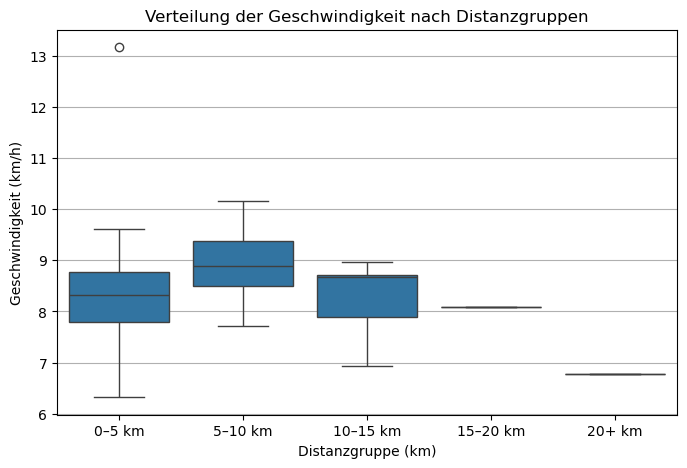

In [44]:


# Distanz in Kategorien einteilen (z. B. kurze, mittlere, lange Läufe)
df["distanz_kategorie"] = pd.cut(
    df["distance_km"],
    bins=[0, 5, 10, 15, 20, 50],
    labels=["0–5 km", "5–10 km", "10–15 km", "15–20 km", "20+ km"]
)

# Boxplot: Geschwindigkeit nach Distanzgruppe
plt.figure(figsize=(8,5))
sns.boxplot(x="distanz_kategorie", y="speed_kmh", data=df)
plt.title("Verteilung der Geschwindigkeit nach Distanzgruppen")
plt.xlabel("Distanzgruppe (km)")
plt.ylabel("Geschwindigkeit (km/h)")
plt.show()
